In [1]:
# =============================================================================
# MJO – SALLJ Compositing
# Wheeler & Hendon (2004) RMM index × Wang & Fu (2004) LLJ index
#
# Methodology:
#   - MJO phases 1-8 from RMM index (Wheeler & Hendon 2004)
#   - Active MJO defined as RMM amplitude > 1.0 (standard threshold)
#   - LLJ anomaly = daily value minus calendar-month mean (removes seasonality)
#   - Significance tested with bootstrap resampling (5000 iterations)
#   - For local test: uses 1995 LLJ data already computed
#   - For HPCC: extend to full historical period for robust composites
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import urllib.request
import os

In [4]:
# =============================================================================
# 1.  LOAD RMM INDEX
# =============================================================================
# The Wheeler-Hendon RMM index is a plain text file from the Australian Bureau
# of Meteorology. It is updated in near-real-time and freely available.
# Columns: year, month, day, RMM1, RMM2, phase, amplitude, source_flag

RMM_URL  = "http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"
RMM_FILE = "rmm_index.txt"

if not os.path.exists(RMM_FILE):
    print("Downloading RMM index from BOM...")
    try:
        urllib.request.urlretrieve(RMM_URL, RMM_FILE)
        print("Downloaded successfully.")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Download manually from:")
        print("  http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt")
        print("and save as 'rmm_index.txt' in your working directory.")
        raise
else:
    print(f"Using cached RMM file: {RMM_FILE}")

# Parse the file — BOM format has a multi-line header, then:
# year  month  day  RMM1  RMM2  phase  amplitude  source_flag
rmm_rows = []
with open(RMM_FILE, 'r') as f:
    for line in f:
        line = line.strip()
        # Skip header lines (they start with letters or are short)
        parts = line.split()
        if len(parts) < 7:
            continue
        try:
            year = int(parts[0])
        except ValueError:
            continue
        rmm_rows.append({
            'year':      int(parts[0]),
            'month':     int(parts[1]),
            'day':       int(parts[2]),
            'rmm1':      float(parts[3]),
            'rmm2':      float(parts[4]),
            'phase':     int(parts[5]),
            'amplitude': float(parts[6]),
        })

rmm = pd.DataFrame(rmm_rows)
rmm['time'] = pd.to_datetime(rmm[['year', 'month', 'day']])
rmm = rmm.set_index('time').drop(columns=['year', 'month', 'day'])

print(f"\nRMM index loaded: {rmm.index[0].date()} to {rmm.index[-1].date()}")
print(f"Total days: {len(rmm)}")
print(f"Phase distribution:\n{rmm['phase'].value_counts().sort_index()}")

Using cached RMM file: rmm_index.txt

RMM index loaded: 1974-06-01 to 2024-02-24
Total days: 18166
Phase distribution:
phase
1      2352
2      2424
3      2154
4      2220
5      2273
6      2194
7      2190
8      2069
999     290
Name: count, dtype: int64


In [5]:
# =============================================================================
# 2.  LOAD LLJ INDEX  (output from sallj_detection_v2.py)
# =============================================================================
# For the local test, load the CSV saved by the detection script.
# On HPCC this would be the full multi-decade series.

llj_df = pd.read_csv('sallj_index.csv', index_col='time', parse_dates=True)
llj_df.index = pd.DatetimeIndex(llj_df.index)

print(f"\nLLJ index loaded: {llj_df.index[0].date()} to {llj_df.index[-1].date()}")
print(f"Total days: {len(llj_df)}")

# =============================================================================
# 3.  REMOVE SEASONAL CYCLE FROM LLJ INDEX
# =============================================================================
# Compositing raw LLJ values by MJO phase would be contaminated by seasonality
# because MJO phases are not uniformly distributed across calendar months.
# Instead, composite the anomaly: daily value minus calendar-month climatology.

monthly_clim = llj_df['llj_index'].groupby(llj_df.index.month).mean()

llj_df['llj_anom'] = llj_df['llj_index'] - llj_df.index.map(
    lambda d: monthly_clim[d.month]
)

print("\nLLJ anomaly stats (seasonal cycle removed):")
print(llj_df['llj_anom'].describe().round(3))


LLJ index loaded: 1995-01-01 to 1995-12-31
Total days: 365

LLJ anomaly stats (seasonal cycle removed):
count    365.000
mean       0.000
std        4.663
min      -12.148
25%       -3.365
50%       -0.406
75%        2.687
max       13.995
Name: llj_anom, dtype: float64


In [7]:
# =============================================================================
# 4.  MERGE LLJ AND RMM
# =============================================================================

# Normalize both indices to date-only — LLJ timestamps are at noon
# (1995-01-01T12:00:00) because MRI-ESM2-0 stores daily means at the day
# midpoint; RMM is at midnight. Inner join finds no matches without this.
llj_df.index  = llj_df.index.normalize()   # floor to 00:00:00
rmm.index     = rmm.index.normalize()

merged = llj_df.join(rmm, how='inner')

merged_active = merged[merged['amplitude'] > 1.0].copy()

n_total  = len(merged)
n_active = len(merged_active)

# Guard against empty merge before computing percentage
if n_total == 0:
    raise ValueError(
        "Merge returned 0 rows even after index normalization.\n"
        f"  LLJ index range:  {llj_df.index[0].date()} to {llj_df.index[-1].date()}\n"
        f"  RMM index range:  {rmm.index[0].date()} to {rmm.index[-1].date()}\n"
        "Check that both cover the same period and that TEST_YEAR is within "
        "the RMM file's date range."
    )

print(f"\nTotal overlapping days:       {n_total}")
print(f"Active MJO days (amp > 1.0):  {n_active} ({100*n_active/n_total:.1f}%)")
print(f"\nSample counts per MJO phase (active days):")
print(merged_active['phase'].value_counts().sort_index())


Total overlapping days:       365
Active MJO days (amp > 1.0):  241 (66.0%)

Sample counts per MJO phase (active days):
phase
1    33
2    32
3    24
4    45
5    30
6    29
7    31
8    17
Name: count, dtype: int64


In [8]:
# =============================================================================
# 5.  COMPUTE COMPOSITES
# =============================================================================

phases = range(1, 9)
composite_mean = {}
composite_std  = {}
composite_n    = {}

for phase in phases:
    vals = merged_active.loc[merged_active['phase'] == phase, 'llj_anom']
    composite_mean[phase] = vals.mean()
    composite_std[phase]  = vals.std()
    composite_n[phase]    = len(vals)

comp_df = pd.DataFrame({
    'mean': composite_mean,
    'std':  composite_std,
    'n':    composite_n,
})
comp_df['se'] = comp_df['std'] / np.sqrt(comp_df['n'])  # standard error

print("\nComposite LLJ anomaly by MJO phase:")
print(comp_df.round(3))


Composite LLJ anomaly by MJO phase:
    mean    std   n     se
1  0.349  6.963  33  1.212
2 -1.586  4.086  32  0.722
3  1.604  3.594  24  0.734
4  0.015  4.256  45  0.634
5 -0.568  3.594  30  0.656
6  0.511  4.562  29  0.847
7 -0.238  3.616  31  0.649
8 -0.291  5.674  17  1.376



Significance results:
    mean   n  p_value  ci_low  ci_high  sig_05  sig_10
1  0.349  33    0.662  -2.005    2.633   False   False
2 -1.586  32    0.052  -2.965   -0.173   False    True
3  1.604  24    0.094   0.240    3.058   False    True
4  0.015  45    0.987  -1.178    1.241   False   False
5 -0.568  30    0.506  -1.835    0.706   False   False
6  0.511  29    0.554  -1.116    2.130   False   False
7 -0.238  31    0.776  -1.463    1.046   False   False
8 -0.291  17    0.799  -2.731    2.554   False   False


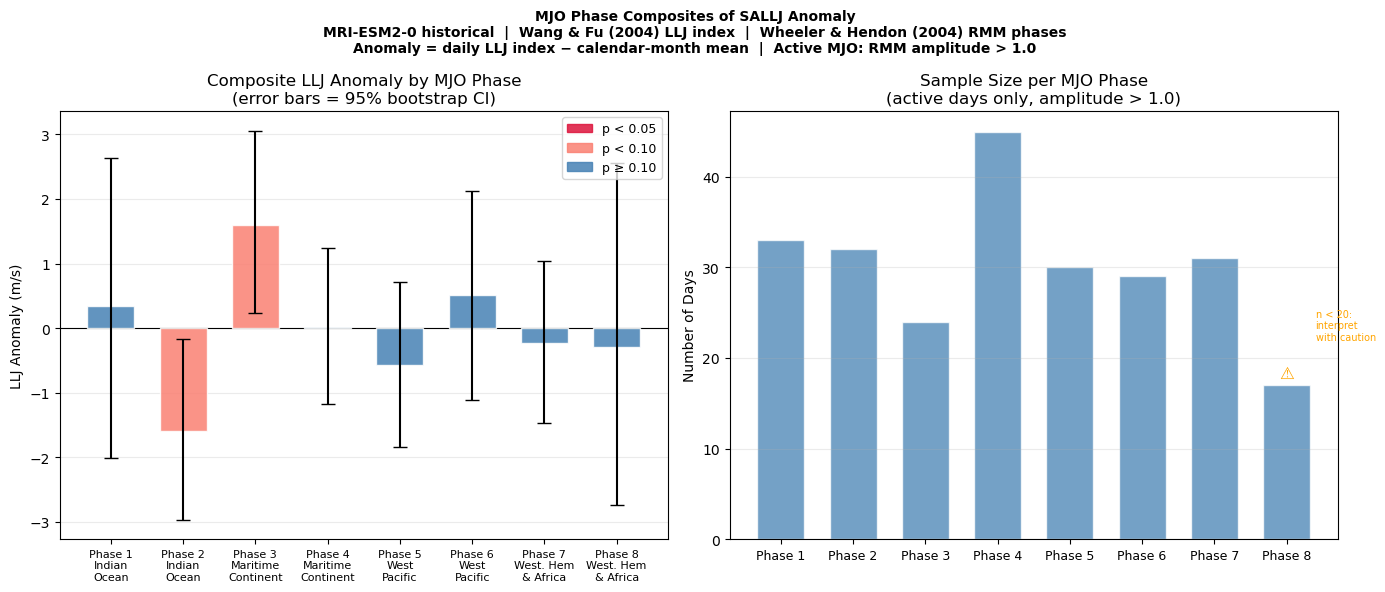


Saved: mjo_sallj_composites.png
Saved: mjo_sallj_composite_table.csv


In [9]:
# =============================================================================
# 6.  BOOTSTRAP SIGNIFICANCE TESTING
# =============================================================================
# Null hypothesis: the LLJ anomaly mean for a given MJO phase is not different
# from the overall active-MJO mean anomaly.
# Method: randomly resample n_phase days from all active days 5000 times,
# compute the mean each time, and check where the observed mean sits in that
# null distribution.

N_BOOTSTRAP = 5000
rng = np.random.default_rng(seed=42)
all_active_anoms = merged_active['llj_anom'].values

p_values = {}
ci_low   = {}
ci_high  = {}

for phase in phases:
    n_phase   = composite_n[phase]
    obs_mean  = composite_mean[phase]

    # Bootstrap null distribution
    boot_means = np.array([
        rng.choice(all_active_anoms, size=n_phase, replace=True).mean()
        for _ in range(N_BOOTSTRAP)
    ])

    # Two-tailed p-value: fraction of bootstrap means as extreme as observed
    p_values[phase] = np.mean(np.abs(boot_means) >= np.abs(obs_mean))

    # 95% confidence interval on the observed mean (bootstrap percentile method)
    obs_boot = np.array([
        merged_active.loc[
            merged_active['phase'] == phase, 'llj_anom'
        ].sample(n=n_phase, replace=True).mean()
        for _ in range(N_BOOTSTRAP)
    ])
    ci_low[phase]  = np.percentile(obs_boot, 2.5)
    ci_high[phase] = np.percentile(obs_boot, 97.5)

comp_df['p_value'] = p_values
comp_df['ci_low']  = ci_low
comp_df['ci_high'] = ci_high
comp_df['sig_05']  = comp_df['p_value'] < 0.05   # significant at 95%
comp_df['sig_10']  = comp_df['p_value'] < 0.10   # significant at 90%

print("\nSignificance results:")
print(comp_df[['mean', 'n', 'p_value', 'ci_low', 'ci_high',
               'sig_05', 'sig_10']].round(3))

# =============================================================================
# 7.  PLOT
# =============================================================================

# MJO phase descriptions (Wheeler & Hendon 2004, Table 1)
# Phases describe where the convective envelope is located
phase_labels = {
    1: "Indian\nOcean",
    2: "Indian\nOcean",
    3: "Maritime\nContinent",
    4: "Maritime\nContinent",
    5: "West\nPacific",
    6: "West\nPacific",
    7: "West. Hem\n& Africa",
    8: "West. Hem\n& Africa",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "MJO Phase Composites of SALLJ Anomaly\n"
    "MRI-ESM2-0 historical  |  Wang & Fu (2004) LLJ index  |  "
    "Wheeler & Hendon (2004) RMM phases\n"
    "Anomaly = daily LLJ index − calendar-month mean  |  "
    "Active MJO: RMM amplitude > 1.0",
    fontsize=10, fontweight='bold'
)

# ── Panel 1: bar chart of composite means + 95% CI ───────────────────────────
ax1 = axes[0]
x = np.arange(1, 9)

colors = []
for phase in phases:
    if comp_df.loc[phase, 'sig_05']:
        colors.append('crimson')
    elif comp_df.loc[phase, 'sig_10']:
        colors.append('salmon')
    else:
        colors.append('steelblue')

bars = ax1.bar(x, comp_df['mean'], color=colors, alpha=0.85, edgecolor='white',
               width=0.65, zorder=3)

# 95% CI error bars
yerr_low  = comp_df['mean'] - comp_df['ci_low']
yerr_high = comp_df['ci_high'] - comp_df['mean']
ax1.errorbar(x, comp_df['mean'],
             yerr=[yerr_low, yerr_high],
             fmt='none', color='black', capsize=5, linewidth=1.5, zorder=4)

ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels([f"Phase {p}\n{phase_labels[p]}" for p in phases],
                    fontsize=8)
ax1.set_ylabel("LLJ Anomaly (m/s)")
ax1.set_title("Composite LLJ Anomaly by MJO Phase\n(error bars = 95% bootstrap CI)")
ax1.grid(alpha=0.25, axis='y', zorder=0)

# Legend for significance colours
patch_sig   = mpatches.Patch(color='crimson', alpha=0.85, label='p < 0.05')
patch_mar   = mpatches.Patch(color='salmon',  alpha=0.85, label='p < 0.10')
patch_insig = mpatches.Patch(color='steelblue', alpha=0.85, label='p ≥ 0.10')
ax1.legend(handles=[patch_sig, patch_mar, patch_insig], fontsize=9,
           loc='upper right')

# ── Panel 2: sample size per phase ───────────────────────────────────────────
ax2 = axes[1]
ax2.bar(x, comp_df['n'], color='steelblue', alpha=0.75, edgecolor='white',
        width=0.65)
ax2.set_xticks(x)
ax2.set_xticklabels([f"Phase {p}" for p in phases], fontsize=9)
ax2.set_ylabel("Number of Days")
ax2.set_title("Sample Size per MJO Phase\n(active days only, amplitude > 1.0)")
ax2.grid(alpha=0.25, axis='y')

# Flag small samples
for phase in phases:
    n = comp_df.loc[phase, 'n']
    if n < 20:
        ax2.text(phase, n + 0.5, '⚠', ha='center', va='bottom',
                 fontsize=12, color='orange')
        ax2.annotate('n < 20:\ninterpret\nwith caution',
                     xy=(phase, n), xytext=(phase + 0.4, n + 5),
                     fontsize=7, color='orange')

plt.tight_layout()
plt.savefig('mjo_sallj_composites.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: mjo_sallj_composites.png")

# =============================================================================
# 8.  SAVE COMPOSITE TABLE
# =============================================================================

comp_df.to_csv('mjo_sallj_composite_table.csv')
print("Saved: mjo_sallj_composite_table.csv")

# =============================================================================
# INTERPRETATION NOTES
# =============================================================================
# MJO phases and their approximate SALLJ implications based on theory:
#
# Phases 7–8:  MJO convective envelope over Western Hemisphere / Africa.
#              Enhanced low-level convergence over South America expected.
#              Theory predicts STRONGER (more negative) LLJ anomaly.
#
# Phases 3–4:  MJO convective envelope over Maritime Continent.
#              Suppressed convection phase over South America.
#              Theory predicts WEAKER (less negative / positive) LLJ anomaly.
#
# If your composites show this pattern, that is a physically meaningful result
# and supports the MJO → SALLJ teleconnection hypothesis.
# Significance will improve substantially on the full historical period (HPCC).
#
# NEXT STEPS:
# 1. Run on full historical period (1979–2014) for robust sample sizes
# 2. Add lag composites: LLJ response at day +1, +2 ... +10 after each phase
#    (MJO is slow; the jet may respond with a lag)
# 3. Compare historical vs ssp585 composites for climate change signal
# =============================================================================


Lag composite sample sizes (phase × lag — should decrease slightly
at longer lags as we run off the end of the LLJ data):
lag    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15
phase                                                                
1      33  33  33  33  33  33  33  33  33  33  33  33  33  33  33  33
2      32  32  32  32  32  32  32  32  32  32  32  32  32  32  32  32
3      24  24  24  24  24  24  24  24  24  24  24  24  24  24  24  24
4      45  45  45  45  45  45  45  45  45  45  45  45  45  45  45  45
5      30  30  30  30  30  30  30  30  30  30  30  30  30  30  30  30
6      29  29  29  29  29  29  29  29  29  29  29  29  29  29  29  29
7      31  31  31  31  31  31  31  31  31  31  31  31  31  30  29  28
8      17  17  17  17  17  17  17  17  17  16  15  14  13  13  13  13

Running lag bootstrap (this takes ~30s locally; ~5s on HPCC)...
Bootstrap complete.


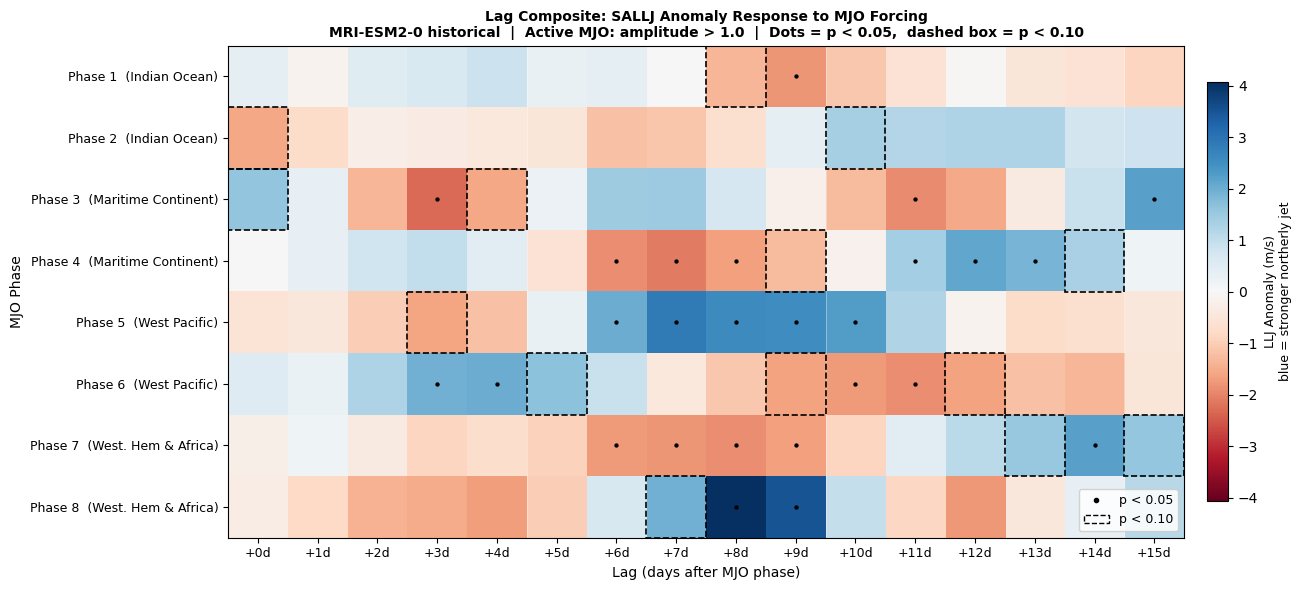


Saved: mjo_sallj_lag_composites.png


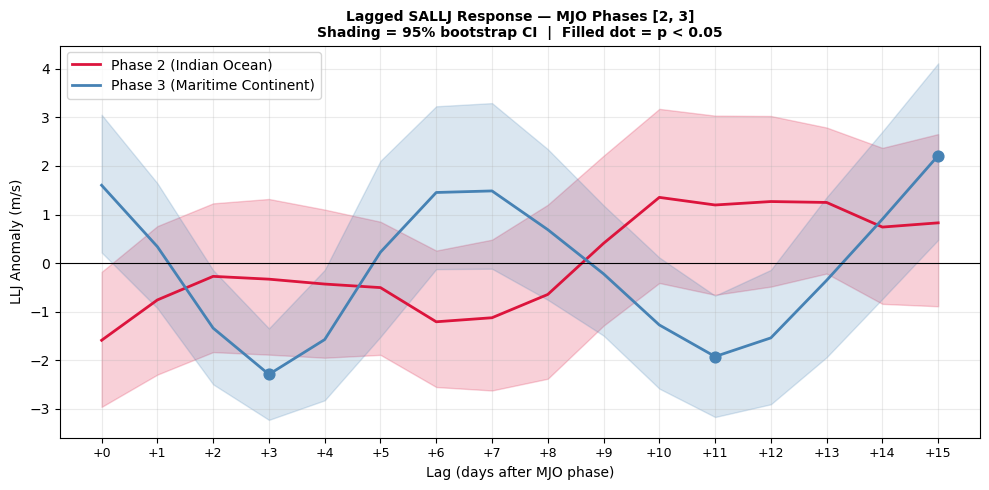

Saved: mjo_sallj_lag_lineplots.png


In [ ]:
# =============================================================================
# 8.  LAG COMPOSITE COMPUTATION
# =============================================================================
# For each MJO phase and each lag day (0 to +15), find all dates where that
# phase was active, then look up the LLJ anomaly lag days later.
#
# This answers: does the SALLJ respond immediately to MJO forcing, or with
# a delay? The MJO propagates at ~5 m/s, so Rossby wave teleconnections to
# South America may take several days to establish.
#
# Lag 0  = same day as MJO phase (same as the composite above)
# Lag +5 = LLJ anomaly 5 days after the MJO phase was recorded
# etc.
 
MAX_LAG = 25   # days — increase to 20+ on the full HPCC run if desired
lags    = range(0, MAX_LAG + 1)
 
# Build a full daily LLJ anomaly series indexed by date for fast lookup
llj_anom_series = llj_df['llj_anom'].copy()
llj_anom_series.index = pd.DatetimeIndex(llj_anom_series.index).normalize()
 
# lag_composites[phase][lag] = array of LLJ anomaly values
lag_composites = {phase: {} for phase in phases}
 
for phase in phases:
    # Dates when this phase was active
    phase_dates = merged_active.loc[
        merged_active['phase'] == phase
    ].index.normalize()
 
    for lag in lags:
        # Shift each phase date forward by lag days
        lagged_dates = phase_dates + pd.Timedelta(days=lag)
 
        # Keep only lagged dates that exist in the LLJ series
        valid = lagged_dates[lagged_dates.isin(llj_anom_series.index)]
        lag_composites[phase][lag] = llj_anom_series.loc[valid].values
 
print("\nLag composite sample sizes (phase × lag — should decrease slightly")
print("at longer lags as we run off the end of the LLJ data):")
size_df = pd.DataFrame(
    {phase: {lag: len(lag_composites[phase][lag]) for lag in lags}
     for phase in phases}
).T
size_df.index.name   = 'phase'
size_df.columns.name = 'lag'
print(size_df.to_string())
 
# =============================================================================
# 9.  BOOTSTRAP SIGNIFICANCE FOR LAG COMPOSITES
# =============================================================================
# Same null hypothesis as before: resample from all active-MJO LLJ anomalies
# to build a null distribution at each lag, then compare to observed mean.
# The same pool of active-MJO anomalies is used at every lag — this is
# standard practice and avoids inflating significance with a lag-specific pool.
 
N_BOOTSTRAP     = 5000
rng_lag         = np.random.default_rng(seed=42)
all_active_pool = llj_anom_series.loc[
    llj_anom_series.index.isin(
        merged_active.index.normalize()
    )
].values
 
# lag_means[phase, lag], lag_pvals[phase, lag]
lag_means = np.full((8, MAX_LAG + 1), np.nan)
lag_pvals = np.full((8, MAX_LAG + 1), np.nan)
lag_ci_lo = np.full((8, MAX_LAG + 1), np.nan)
lag_ci_hi = np.full((8, MAX_LAG + 1), np.nan)
 
print("\nRunning lag bootstrap (this takes ~30s locally; ~5s on HPCC)...")
 
for phase in phases:
    for lag in lags:
        vals = lag_composites[phase][lag]
        n    = len(vals)
        if n < 3:          # skip if too few samples at this lag
            continue
 
        obs_mean = vals.mean()
        lag_means[phase - 1, lag] = obs_mean
 
        # Null distribution
        boot_null = np.array([
            rng_lag.choice(all_active_pool, size=n, replace=True).mean()
            for _ in range(N_BOOTSTRAP)
        ])
        lag_pvals[phase - 1, lag] = np.mean(
            np.abs(boot_null) >= np.abs(obs_mean)
        )
 
        # 95% CI on observed mean
        boot_obs = np.array([
            rng_lag.choice(vals, size=n, replace=True).mean()
            for _ in range(N_BOOTSTRAP)
        ])
        lag_ci_lo[phase - 1, lag] = np.percentile(boot_obs, 2.5)
        lag_ci_hi[phase - 1, lag] = np.percentile(boot_obs, 97.5)
 
print("Bootstrap complete.")
 
# =============================================================================
# 10.  LAG COMPOSITE PLOT  —  heatmap  (phase × lag)
# =============================================================================
# Standard format in MJO teleconnection literature.
# Stippling marks grid cells where p < 0.05.
# Hatching marks p < 0.10.
 
fig2, ax = plt.subplots(figsize=(14, 6))
 
# Colour scale: symmetric around zero, blue = stronger northerly jet,
# red = weaker/southerly jet — physically meaningful for the SALLJ
vmax = np.nanmax(np.abs(lag_means))
vmax = max(vmax, 0.5)    # floor so colorbar is readable on short test runs
 
im = ax.imshow(
    lag_means,
    aspect='auto',
    origin='upper',
    extent=[-0.5, MAX_LAG + 0.5, 8.5, 0.5],
    cmap='RdBu',           # red = positive (southerly), blue = negative (northerly)
    vmin=-vmax, vmax=vmax,
    interpolation='nearest',
)
 
cbar = fig2.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label("LLJ Anomaly (m/s)\nblue = stronger northerly jet", fontsize=9)
 
# ── Stippling: p < 0.05 ──────────────────────────────────────────────────────
sig05_y, sig05_x = np.where(lag_pvals < 0.05)
if len(sig05_x) > 0:
    ax.scatter(
        sig05_x, sig05_y + 1,   # +1 because phase labels are 1-indexed
        marker='.', color='black', s=18, zorder=5,
        label='p < 0.05'
    )
 
# ── Hatching outline: p < 0.10 ───────────────────────────────────────────────
# Draw a small square outline around marginally significant cells
for (pi, li) in zip(*np.where((lag_pvals < 0.10) & (lag_pvals >= 0.05))):
    rect = plt.Rectangle(
        (li - 0.5, pi + 0.5), 1, 1,
        linewidth=1.2, edgecolor='black',
        facecolor='none', linestyle='--', zorder=5
    )
    ax.add_patch(rect)
 
# ── Axes labels ──────────────────────────────────────────────────────────────
ax.set_xticks(range(0, MAX_LAG + 1))
ax.set_xticklabels([f"+{l}d" for l in range(0, MAX_LAG + 1)], fontsize=9)
ax.set_yticks(range(1, 9))
ax.set_yticklabels(
    [f"Phase {p}  ({phase_labels[p].replace(chr(10), ' ')})"
     for p in phases],
    fontsize=9
)
ax.set_xlabel("Lag (days after MJO phase)", fontsize=10)
ax.set_ylabel("MJO Phase", fontsize=10)
ax.set_title(
    "Lag Composite: SALLJ Anomaly Response to MJO Forcing\n"
    "MRI-ESM2-0 historical  |  Active MJO: amplitude > 1.0  |  "
    "Dots = p < 0.05,  dashed box = p < 0.10",
    fontsize=10, fontweight='bold'
)
 
# ── Vertical reference lines every 5 days ────────────────────────────────────
for l in range(0, MAX_LAG + 1, 5):
    ax.axvline(l - 0.5, color='white', lw=0.5, alpha=0.5)
 
# ── Legend ───────────────────────────────────────────────────────────────────
dot_handle = plt.Line2D([0], [0], marker='.', color='black',
                         linestyle='none', markersize=6, label='p < 0.05')
box_handle = mpatches.Patch(facecolor='none', edgecolor='black',
                              linestyle='--', label='p < 0.10')
ax.legend(handles=[dot_handle, box_handle], fontsize=9,
          loc='lower right', framealpha=0.85)
 
plt.tight_layout()
plt.savefig('mjo_sallj_lag_composites.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: mjo_sallj_lag_composites.png")
 
# ── Also plot line traces for the two most interesting phases ─────────────────
# Useful for inspecting the shape of the lagged response in detail.
# Edit HIGHLIGHT_PHASES to whichever phases showed the strongest signal above.
HIGHLIGHT_PHASES = [2, 3]
 
fig3, ax3 = plt.subplots(figsize=(10, 5))
colors_highlight = ['crimson', 'steelblue', 'forestgreen', 'darkorange']
 
for i, phase in enumerate(HIGHLIGHT_PHASES):
    means  = lag_means[phase - 1, :]
    ci_lo  = lag_ci_lo[phase - 1, :]
    ci_hi  = lag_ci_hi[phase - 1, :]
    color  = colors_highlight[i % len(colors_highlight)]
    lags_x = np.array(list(lags))
 
    ax3.plot(lags_x, means, color=color, lw=2,
             label=f"Phase {phase} ({phase_labels[phase].replace(chr(10), ' ')})")
    ax3.fill_between(lags_x, ci_lo, ci_hi, alpha=0.2, color=color)
 
    # Mark significant lags with a filled dot
    for lag in lags:
        if lag_pvals[phase - 1, lag] < 0.05:
            ax3.scatter(lag, means[lag], color=color, s=60, zorder=5)
 
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(list(lags))
ax3.set_xticklabels([f"+{l}" for l in lags], fontsize=9)
ax3.set_xlabel("Lag (days after MJO phase)", fontsize=10)
ax3.set_ylabel("LLJ Anomaly (m/s)", fontsize=10)
ax3.set_title(
    f"Lagged SALLJ Response — MJO Phases {HIGHLIGHT_PHASES}\n"
    "Shading = 95% bootstrap CI  |  Filled dot = p < 0.05",
    fontsize=10, fontweight='bold'
)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.25)
 
plt.tight_layout()
plt.savefig('mjo_sallj_lag_lineplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mjo_sallj_lag_lineplots.png")

In [ ]:
# =============================================================================
# 11.  SAVE ALL OUTPUTS
# =============================================================================
 
comp_df.to_csv('mjo_sallj_composite_table.csv')
print("Saved: mjo_sallj_composite_table.csv")
 
# Save lag composite arrays as a tidy DataFrame
lag_rows = []
for phase in phases:
    for lag in lags:
        lag_rows.append({
            'phase':   phase,
            'lag':     lag,
            'mean':    lag_means[phase - 1, lag],
            'p_value': lag_pvals[phase - 1, lag],
            'ci_low':  lag_ci_lo[phase - 1, lag],
            'ci_high': lag_ci_hi[phase - 1, lag],
            'n':       len(lag_composites[phase][lag]),
        })
 
lag_df = pd.DataFrame(lag_rows)
lag_df.to_csv('mjo_sallj_lag_composite_table.csv', index=False)
print("Saved: mjo_sallj_lag_composite_table.csv")
 
# =============================================================================
# INTERPRETATION NOTES
# =============================================================================
# MJO phases and their approximate SALLJ implications based on theory:
#
# Phases 7–8:  MJO convective envelope over Western Hemisphere / Africa.
#              Enhanced low-level convergence over South America expected.
#              Theory predicts STRONGER (more negative) LLJ anomaly.
#
# Phases 3–4:  MJO convective envelope over Maritime Continent.
#              Suppressed convection phase over South America.
#              Theory predicts WEAKER (less negative / positive) LLJ anomaly.
#
# For the lag composites, look for:
#   - A lag of 5–10 days for the peak response — consistent with Rossby wave
#     propagation from the Indo-Pacific warm pool to South America
#   - Coherent sign transitions across consecutive phases at the same lag —
#     this is the strongest evidence for a real teleconnection vs. noise
#   - On the 1-year test, most lags will be insignificant — that is expected.
#     On the full HPCC run (1979–2014, ~35x more data) you should see robust
#     stippling emerge, particularly for phases 2–3 which were already
#     significant at lag 0.
#
# NEXT STEPS:
# 1. Run on full historical period (1979–2014) for robust sample sizes
# 2. Separate by austral season (DJF/MAM/JJA/SON) — Wang & Fu showed the
#    LLJ mechanism differs by season, so the MJO response likely does too
# 3. Compare historical vs ssp585 lag composites for climate change signal
# 4. Add 850-hPa wind vector composites (ua + va) to map the spatial pattern
#    of the SALLJ response, not just the index timeseries
# =============================================================================